In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("River_Plastic_Waste_Risk_Scenarios_2015_2060.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   River_ID                    3000 non-null   int64  
 1   River_Name                  3000 non-null   object 
 2   Country                     3000 non-null   object 
 3   Continent                   3000 non-null   object 
 4   Population_2015             3000 non-null   int64  
 5   Population_2060             3000 non-null   int64  
 6   Waste_Generation_2015_tons  3000 non-null   float64
 7   Waste_Generation_2060_tons  3000 non-null   float64
 8   Plastic_Waste_2015_tons     3000 non-null   float64
 9   Plastic_Waste_2060_tons     3000 non-null   float64
 10  Mismanaged_Waste_2015_tons  3000 non-null   float64
 11  Mismanaged_Waste_2060_tons  3000 non-null   float64
 12  Plastic_to_River_2015_tons  3000 non-null   float64
 13  Plastic_to_River_2060_tons  3000 

,River_ID,Population_2015,Population_2060,Waste_Generation_2015_tons,Waste_Generation_2060_tons,Plastic_Waste_2015_tons,Plastic_Waste_2060_tons,Mismanaged_Waste_2015_tons,Mismanaged_Waste_2060_tons,Plastic_to_River_2015_tons,...,Basin_Area_km2,Urbanization_2015_pct,Urbanization_2060_pct,GDP_per_capita_2015,GDP_per_capita_2060,Policy_Strength_2015,Policy_Strength_2060,Waste_Collection_Rate_2015,Waste_Collection_Rate_2060,Risk_Score_Change
count,3000.000000,3.000000e+03,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,9.902995e+06,1.439333e+07,9937.108593,15722.462520,1972.420450,3944.802205,984.794046,1599.795419,246.130444,...,255050.174161,50.057792,62.708560,12788.280554,23538.089370,0.497450,0.741778,0.553076,0.720815,35.788421
std,866.169729,5.768554e+06,8.701584e+06,6695.912177,10601.295790,1486.016108,2857.043089,792.936969,1292.345791,225.795829,...,145043.553125,17.206687,17.699645,6983.325528,13866.334802,0.287451,0.248651,0.199433,0.200259,280.864915
min,1.000000,1.002450e+05,1.488670e+05,97.433964,112.888574,17.274615,24.166990,7.181986,5.941984,1.340865,...,1224.065038,20.000332,25.893246,521.003622,765.286423,0.000125,0.110998,0.200072,0.256240,-1246.002148
25%,750.750000,4.877241e+06,6.893512e+06,4430.943455,7201.296054,825.059031,1713.877218,369.395386,634.996615,81.662342,...,128174.188742,35.462172,48.265934,6834.986397,11996.601860,0.248929,0.537364,0.385712,0.559278,-78.293886
50%,1500.500000,9.838680e+06,1.410217e+07,9107.858721,14318.548919,1665.601032,3441.779457,797.706275,1297.788773,182.009292,...,257727.765870,49.801801,62.709587,12924.714742,22850.505800,0.492732,0.784064,0.550619,0.733963,6.131354
75%,2250.250000,1.487036e+07,2.103804e+07,14079.641695,22424.598839,2774.576420,5520.531338,1381.727937,2213.311950,340.324187,...,381416.629634,64.783787,76.976344,18927.486649,33499.182090,0.748619,1.000000,0.729408,0.899346,132.037426
max,3000.000000,1.999544e+07,3.526011e+07,29269.926629,54578.093316,8317.527382,15193.460738,4969.205532,8550.722397,1869.833226,...,499450.744236,79.963753,99.299629,24991.072823,60813.487769,0.999501,1.000000,0.899488,1.000000,2036.613754


In [3]:
df.isnull().sum()

River_ID                      0
River_Name                    0
Country                       0
Continent                     0
Population_2015               0
Population_2060               0
Waste_Generation_2015_tons    0
Waste_Generation_2060_tons    0
Plastic_Waste_2015_tons       0
Plastic_Waste_2060_tons       0
Mismanaged_Waste_2015_tons    0
Mismanaged_Waste_2060_tons    0
Plastic_to_River_2015_tons    0
Plastic_to_River_2060_tons    0
River_Length_km               0
Basin_Area_km2                0
Urbanization_2015_pct         0
Urbanization_2060_pct         0
GDP_per_capita_2015           0
GDP_per_capita_2060           0
Policy_Strength_2015          0
Policy_Strength_2060          0
Waste_Collection_Rate_2015    0
Waste_Collection_Rate_2060    0
Risk_Score_Change             0
dtype: int64

In [4]:
print(df.columns.tolist())


['River_ID', 'River_Name', 'Country', 'Continent', 'Population_2015', 'Population_2060', 'Waste_Generation_2015_tons', 'Waste_Generation_2060_tons', 'Plastic_Waste_2015_tons', 'Plastic_Waste_2060_tons', 'Mismanaged_Waste_2015_tons', 'Mismanaged_Waste_2060_tons', 'Plastic_to_River_2015_tons', 'Plastic_to_River_2060_tons', 'River_Length_km', 'Basin_Area_km2', 'Urbanization_2015_pct', 'Urbanization_2060_pct', 'GDP_per_capita_2015', 'GDP_per_capita_2060', 'Policy_Strength_2015', 'Policy_Strength_2060', 'Waste_Collection_Rate_2015', 'Waste_Collection_Rate_2060', 'Risk_Score_Change']


In [5]:
# Create new features for analysis
df['Waste_Per_Capita_2015'] = df['Plastic_Waste_2015_tons'] / df['Population_2015']
df['Waste_Per_Capita_2060'] = df['Plastic_Waste_2060_tons'] / df['Population_2060']

df['Risk_Density_2015'] = df['Plastic_to_River_2015_tons'] / df['River_Length_km']
df['Risk_Density_2060'] = df['Plastic_to_River_2060_tons'] / df['River_Length_km']

df['Population_Change_Rate'] = (df['Population_2060'] - df['Population_2015']) / 45
df['Waste_Change_Rate'] = (df['Plastic_Waste_2060_tons'] - df['Plastic_Waste_2015_tons']) / 45
df['Urbanization_Change_Rate'] = (df['Urbanization_2060_pct'] - df['Urbanization_2015_pct']) / 45

df.head()

,River_ID,River_Name,Country,Continent,Population_2015,Population_2060,Waste_Generation_2015_tons,Waste_Generation_2060_tons,Plastic_Waste_2015_tons,Plastic_Waste_2060_tons,...,Waste_Collection_Rate_2015,Waste_Collection_Rate_2060,Risk_Score_Change,Waste_Per_Capita_2015,Waste_Per_Capita_2060,Risk_Density_2015,Risk_Density_2060,Population_Change_Rate,Waste_Change_Rate,Urbanization_Change_Rate
0,1,River_0,Brazil,South America,16194478,26111907,17792.200652,19741.088429,2334.317226,3190.490009,...,0.403860,0.606824,-393.971968,0.000144,0.000122,0.194316,0.031939,220387.311111,19.026062,0.171719
1,2,River_1,Vietnam,Asia,13337723,23762872,9773.501161,16410.792306,2186.109392,3716.919707,...,0.678284,0.880784,-226.234377,0.000164,0.000156,0.470271,0.274180,231669.977778,34.018007,0.298874
2,3,River_2,USA,North America,13579854,16585826,12100.472956,12974.031643,3038.093359,3049.301900,...,0.791174,1.000000,211.992452,0.000224,0.000184,0.110555,0.294593,66799.377778,0.249079,0.353535
3,4,River_3,DR Congo,Africa,2804238,4711445,2402.540235,4150.474491,501.023859,739.551654,...,0.281108,0.546884,-81.894650,0.000179,0.000157,0.229497,0.076951,42382.377778,5.300618,0.346730
4,5,River_4,Nigeria,Africa,17873323,23800628,10072.660424,21681.951354,1662.358278,6416.149836,...,0.275524,0.333381,61.485910,0.000093,0.000270,0.124049,0.158256,131717.888889,105.639812,0.368100


In [7]:
# Define features and target
feature_columns = [
    'Population_2015',
    'Waste_Generation_2015_tons',
    'Plastic_Waste_2015_tons',
    'Mismanaged_Waste_2015_tons',
    'Plastic_to_River_2015_tons',
    'River_Length_km',
    'Basin_Area_km2',
    'Urbanization_2015_pct',
    'GDP_per_capita_2015',
    'Policy_Strength_2015',
    'Waste_Collection_Rate_2015',
    'Waste_Per_Capita_2015',
    'Risk_Density_2015'
]

X = df[feature_columns]
y = df['Plastic_Waste_2060_tons']

In [8]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Risk Category
def categorize_risk(score):
    if score < 0.3:
        return 'Low'
    elif score < 0.6:
        return 'Medium'
    else:
        return 'High'

df['Risk_Category_2015'] = df['Risk_Density_2015'].apply(categorize_risk)
df['Risk_Category_2060'] = df['Risk_Density_2060'].apply(categorize_risk)

df.head()

,River_ID,River_Name,Country,Continent,Population_2015,Population_2060,Waste_Generation_2015_tons,Waste_Generation_2060_tons,Plastic_Waste_2015_tons,Plastic_Waste_2060_tons,...,Risk_Score_Change,Waste_Per_Capita_2015,Waste_Per_Capita_2060,Risk_Density_2015,Risk_Density_2060,Population_Change_Rate,Waste_Change_Rate,Urbanization_Change_Rate,Risk_Category_2015,Risk_Category_2060
0,1,River_0,Brazil,South America,16194478,26111907,17792.200652,19741.088429,2334.317226,3190.490009,...,-393.971968,0.000144,0.000122,0.194316,0.031939,220387.311111,19.026062,0.171719,Low,Low
1,2,River_1,Vietnam,Asia,13337723,23762872,9773.501161,16410.792306,2186.109392,3716.919707,...,-226.234377,0.000164,0.000156,0.470271,0.274180,231669.977778,34.018007,0.298874,Medium,Low
2,3,River_2,USA,North America,13579854,16585826,12100.472956,12974.031643,3038.093359,3049.301900,...,211.992452,0.000224,0.000184,0.110555,0.294593,66799.377778,0.249079,0.353535,Low,Low
3,4,River_3,DR Congo,Africa,2804238,4711445,2402.540235,4150.474491,501.023859,739.551654,...,-81.894650,0.000179,0.000157,0.229497,0.076951,42382.377778,5.300618,0.346730,Low,Low
4,5,River_4,Nigeria,Africa,17873323,23800628,10072.660424,21681.951354,1662.358278,6416.149836,...,61.485910,0.000093,0.000270,0.124049,0.158256,131717.888889,105.639812,0.368100,Low,Low


In [11]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2400, 13)
Test set shape: (600, 13)


EDA

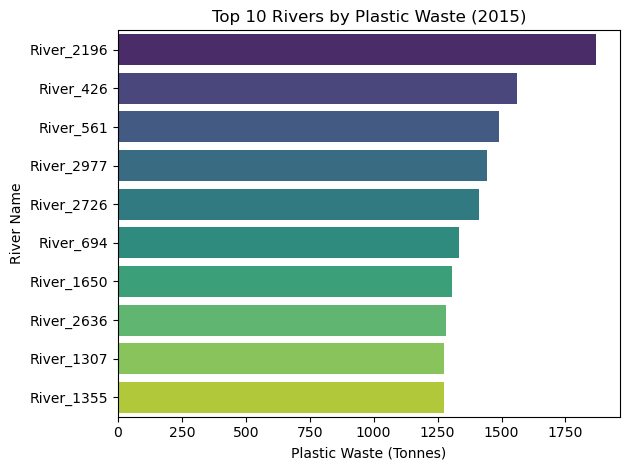

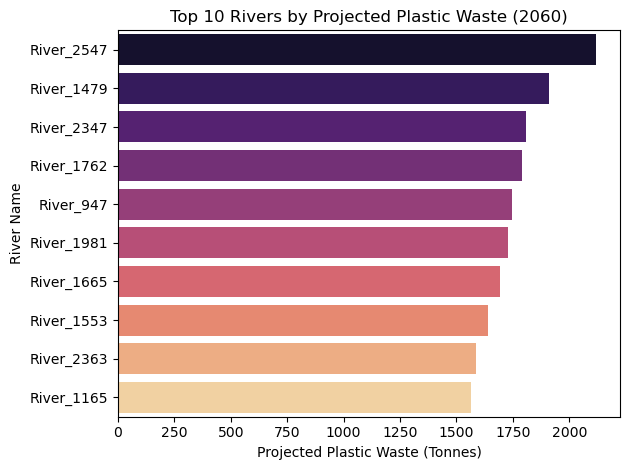

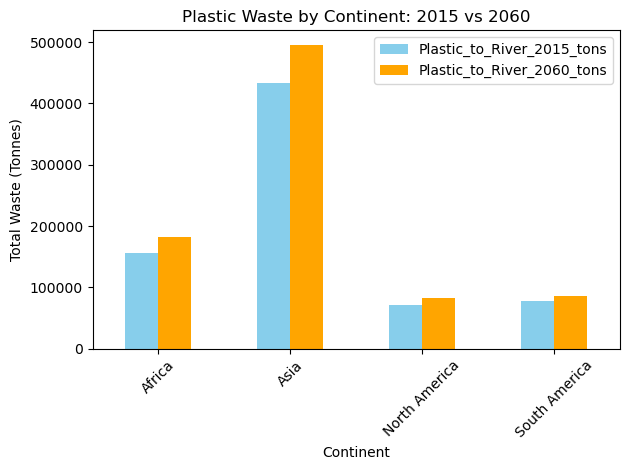

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 rivers by plastic waste in 2015
top_2015 = df.nlargest(10, 'Plastic_to_River_2015_tons')
sns.barplot(data=top_2015, x='Plastic_to_River_2015_tons', y='River_Name', palette='viridis')
plt.title("Top 10 Rivers by Plastic Waste (2015)")
plt.xlabel("Plastic Waste (Tonnes)")
plt.ylabel("River Name")
plt.tight_layout()
plt.show()

# Top 10 rivers by projected plastic waste in 2060
top_2060 = df.nlargest(10, 'Plastic_to_River_2060_tons')
sns.barplot(data=top_2060, x='Plastic_to_River_2060_tons', y='River_Name', palette='magma')
plt.title("Top 10 Rivers by Projected Plastic Waste (2060)")
plt.xlabel("Projected Plastic Waste (Tonnes)")
plt.ylabel("River Name")
plt.tight_layout()
plt.show()

# Continent trend comparison
df_grouped = df.groupby('Continent')[['Plastic_to_River_2015_tons', 'Plastic_to_River_2060_tons']].sum().reset_index()
df_grouped.plot(x='Continent', kind='bar', stacked=False, color=['skyblue', 'orange'])
plt.title("Plastic Waste by Continent: 2015 vs 2060")
plt.xlabel("Continent")
plt.ylabel("Total Waste (Tonnes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

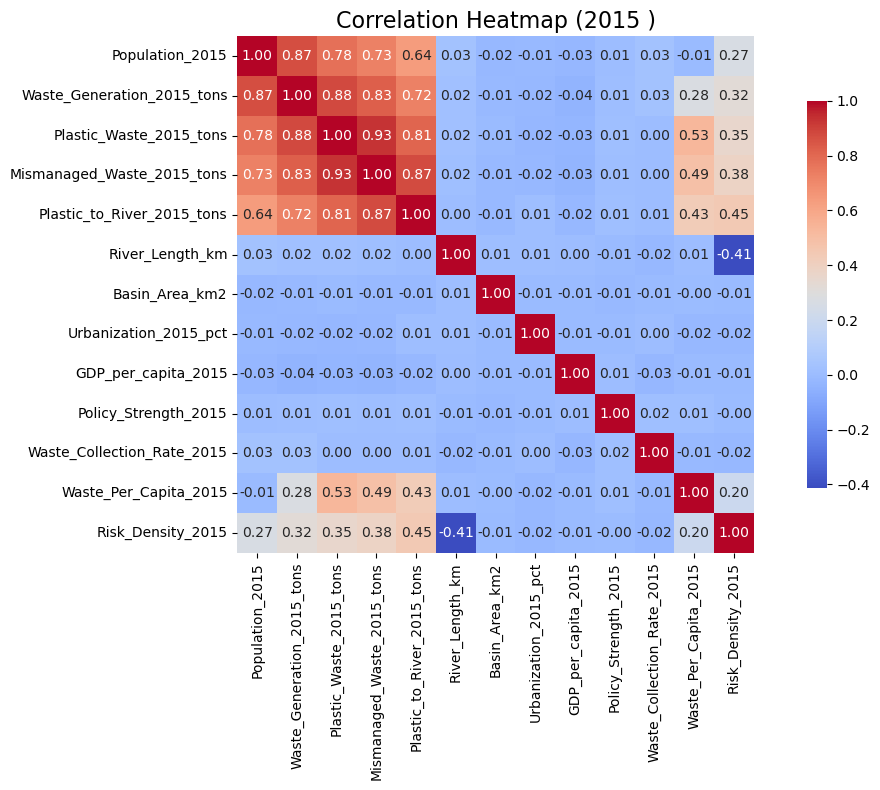

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only 2015-related columns
columns_2015 = [
    'Population_2015',
    'Waste_Generation_2015_tons',
    'Plastic_Waste_2015_tons',
    'Mismanaged_Waste_2015_tons',
    'Plastic_to_River_2015_tons',
    'River_Length_km',
    'Basin_Area_km2',
    'Urbanization_2015_pct',
    'GDP_per_capita_2015',
    'Policy_Strength_2015',
    'Waste_Collection_Rate_2015',
    'Waste_Per_Capita_2015',
    'Risk_Density_2015'
]

# Subset DataFrame
df_2015 = df[columns_2015]

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_2015.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": 0.75})
plt.title("Correlation Heatmap (2015 )", fontsize=16)
plt.tight_layout()
plt.show()


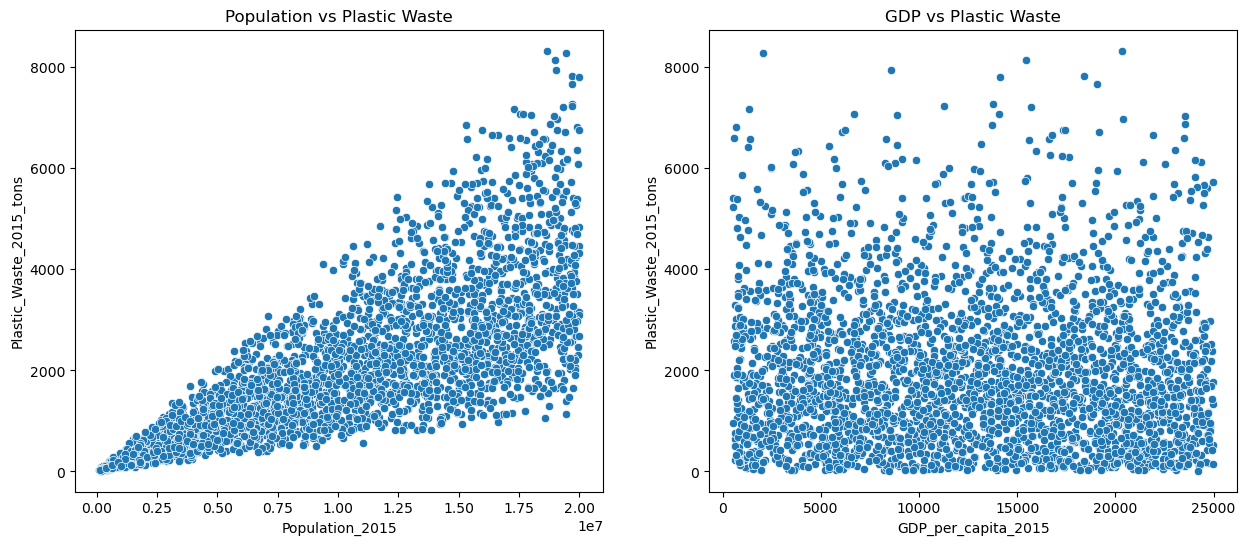

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='Population_2015', y='Plastic_Waste_2015_tons', ax=axes[0])
axes[0].set_title('Population vs Plastic Waste')

sns.scatterplot(data=df, x='GDP_per_capita_2015', y='Plastic_Waste_2015_tons', ax=axes[1])
axes[1].set_title('GDP vs Plastic Waste')

    
plt.show()